In [7]:
# Library yang sering digunakan
import os
import io
import matplotlib.pyplot as plt
from google.colab import drive
#Hubungkan ke Google Drive
drive.mount('/content/drive')
import shutil
import zipfile
import glob
import random
from random import sample
import shutil
from shutil import copyfile
import pathlib
from pathlib import Path
import numpy as np
import seaborn as sns
import pandas as pd
from tqdm.notebook import tqdm as tq
from google.colab import files

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# Libraries untuk pemrosesan data gambar
import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate as sk_rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

In [9]:
# Libraries untuk pembangunan model
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.applications import EfficientNetB0, MobileNetV2
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocessing

In [10]:

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [ ]:
import kagglehub

download_path = kagglehub.dataset_download("vencerlanz09/sea-animals-image-dataste")

print("Path to dataset files: ", download_path)

100%|██████████| 312M/312M [00:05<00:00, 61.4MB/s]

Extracting files...


Path to dataset files:  /root/.cache/kagglehub/datasets/vencerlanz09/sea-animals-image-dataste/versions/5


Isi folder: ['Starfish', 'Seahorse', 'Lobster', 'Eel', 'Puffers', 'Sharks', 'Dolphin', 'Otter', 'Corals', 'Seal', 'Nudibranchs', 'Sea Urchins', 'Octopus', 'Shrimp', 'Sea Rays', 'Penguin', 'Jelly Fish', 'Turtle_Tortoise', 'Clams', 'Squid', 'Crabs', 'Fish', 'Whale']


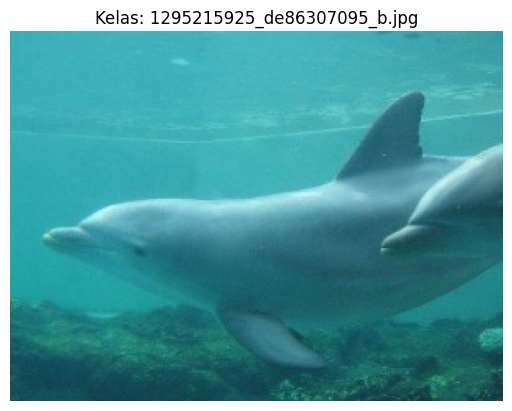

In [ ]:
#menulusuri isi folder
folder = os.listdir(download_path)
print("Isi folder:", folder)

#Menambil satu contoh gambar
data_dir = os.path.join(download_path, 'Dolphin')

img_name = os.listdir(os.path.join(data_dir))[0]
img_path = os.path.join(data_dir, img_name)

#Membaca dan menampilkan gambar
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) #konversi warna untuk matplotlib

plt.imshow(img)
plt.title(f"Kelas: {img_name}")
plt.axis('off')
plt.show()

In [ ]:
#Melihat jumha file gambar
ttl_gambar = 0

for root, dirs, files in os.walk(download_path):
    #filter file gambar untuk akurasi
    images = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg', '.webp')) ]
    ttl_gambar += len(images)

print(f"Total number of images in the dataset: {ttl_gambar}")

Total number of images in the dataset: 13711


In [ ]:
#Melihat per kategori
categ = sorted(os.listdir(download_path))

print(f"{'Kategori':<20} | {'Jumlah Gambar'}")
print("-" * 35)

for cat in categ:
  cat_path = os.path.join(download_path, cat)
  if os.path.isdir(cat_path):
    n_img = len([f for f in os.listdir(cat_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    print(f"{cat:<20} | {n_img}")

Kategori             | Jumlah Gambar
-----------------------------------
Clams                | 497
Corals               | 500
Crabs                | 499
Dolphin              | 782
Eel                  | 497
Fish                 | 494
Jelly Fish           | 845
Lobster              | 499
Nudibranchs          | 500
Octopus              | 562
Otter                | 500
Penguin              | 482
Puffers              | 531
Sea Rays             | 517
Sea Urchins          | 579
Seahorse             | 478
Seal                 | 414
Sharks               | 590
Shrimp               | 488
Squid                | 483
Starfish             | 499
Turtle_Tortoise      | 1903
Whale                | 572


The image dataset in this submission consists of 13,711 images across several categories, with the 'Turtle_Tortoise' category containing the highest number of images at 1,903.

In [ ]:
#Menyalin dataset ke google drive
#Hubungkan ke Google Drive
drive.mount('/content/drive')

#Tentukan nama folder tujuan di Google Drive
destination_path = '/content/drive/MyDrive/Computer_Vision/Dataset_Sea_Animals'


#Proses menyalin folder dari Kagglehub ke Google Drive
try:
    if 'download_path' in locals():
        print(f"Sedang menyalin data dari: {download_path}")
        shutil.copytree(download_path, destination_path, dirs_exist_ok=True)
        print(f"✅ Berhasil! Dataset sekarang ada di: {destination_path}")
    else:
        print("❌ Error: Variabel 'path' tidak ditemukan. Silakan jalankan ulang baris kagglehub.dataset_download tadi.")
except Exception as e:
    print(f"❌ Terjadi kesalahan saat menyalin: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Sedang menyalin data dari: /root/.cache/kagglehub/datasets/vencerlanz09/sea-animals-image-dataste/versions/5
✅ Berhasil! Dataset sekarang ada di: /content/drive/MyDrive/Computer_Vision/Dataset_Sea_Animals


## **Data Preparation**

In [ ]:
#Mengubah nama file gambar sesuai nama folder

#defenisikan path penyimpanan gambar
root_path = '/content/drive/MyDrive/Computer_Vision/Dataset_Sea_Animals'

def rename_sea_animals_dataset(root_path):
    if not os.path.exists(root_path):
        print(f"Eror: Path {root_path} tidak ditemukan")
        return

    #Iterasi melalui folder hewan laut
    for folder_name in os.listdir(root_path):
        folder_path = os.path.join(root_path, folder_name)

        if os.path.isdir(folder_path):
            print(f"Processing: {folder_name}")

            #Ambil semua file dan urutkan agar rapi
            files = sorted(os.listdir(folder_path))

            counter = 1
            for filename in files:
                ext = os.path.splitext(filename)[1].lower()
                #Filter hanya file gambar
                if ext in ['.jpg', '.jpeg', '.png', '.bmp', '.webp']:
                    #format nama: Namahewan_001.jpg
                    new_name = f"{folder_name}_{counter:03d}{ext}"

                    old_file = os.path.join(folder_path, filename)
                    new_file = os.path.join(folder_path, new_name)

                    try:
                        os.rename(old_file, new_file)
                        counter += 1
                    except Exception as e:
                        print(f"Failed to change {filename}: {e}")

        print(f"\nProcess complete! All marine animal images have been renamed.")

#proses rename
rename_sea_animals_dataset(root_path)

Processing: Starfish

Process complete! All marine animal images have been renamed.
Processing: Seahorse

Process complete! All marine animal images have been renamed.
Processing: Lobster

Process complete! All marine animal images have been renamed.
Processing: Eel

Process complete! All marine animal images have been renamed.
Processing: Puffers

Process complete! All marine animal images have been renamed.
Processing: Sharks

Process complete! All marine animal images have been renamed.
Processing: Dolphin

Process complete! All marine animal images have been renamed.
Processing: Otter

Process complete! All marine animal images have been renamed.
Processing: Corals

Process complete! All marine animal images have been renamed.
Processing: Seal

Process complete! All marine animal images have been renamed.
Processing: Nudibranchs

Process complete! All marine animal images have been renamed.
Processing: Sea Urchins

Process complete! All marine animal images have been renamed.
Proce

Data preparation involves preparing the data by saving all images to Google Drive, thereby eliminating the need to repeatedly request access to the Kaggle dataset. Additionally, to make the images easier to identify, the file names are renamed to match the storage folder name followed by a sequential number.

## **Dataset Checking**

This section prepares the dataset that will be used to train the model.

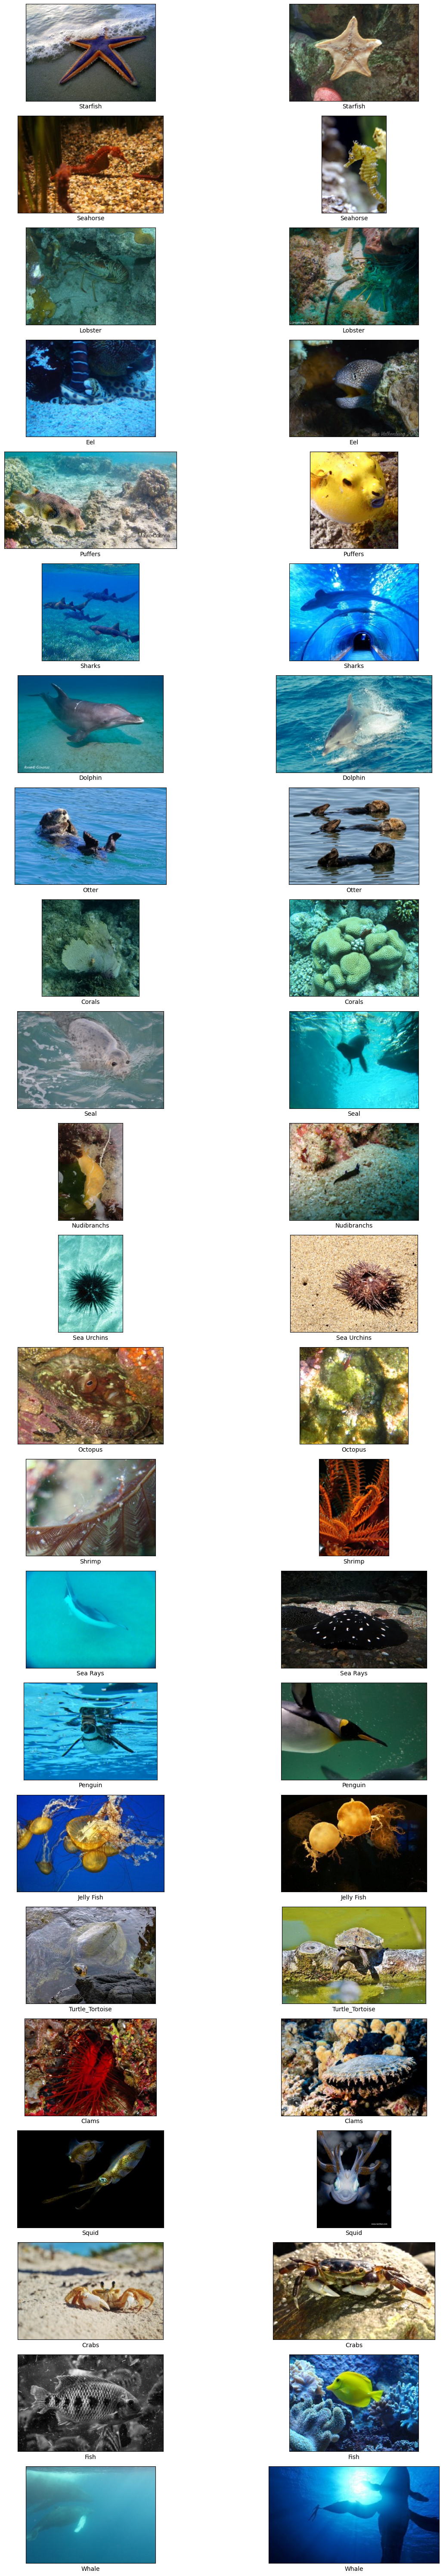

In [ ]:
#Membuat kamus yang menyimpan gambar untuk setiap kelas dalam data
animal_img ={}

#tentukan path sumber
path = "/content/drive/MyDrive/Computer_Vision"

path_sub = os.path.join(path, 'Dataset_Sea_Animals')
for i in os.listdir(path_sub):
    full_sub_path = os.path.join(path_sub, i)
    # Pastikan hanya memproses jika itu adalah folder
    if os.path.isdir(full_sub_path):
        animal_img[i] = os.listdir(full_sub_path)

#Menampilkan secara acak 5 gambar dibawah setiap dari 23 kelas data
fig, axs = plt.subplots(len(animal_img.keys()), 2, figsize=(15, 60))

for i, class_name in enumerate(animal_img.keys()):
    img = np.random.choice(animal_img[class_name], 2, replace=False)

    for j, img_name in enumerate(img):
        img_path = os.path.join(path_sub, class_name, img_name)
        images = Image.open(img_path).convert("RGB") #Konversi menjadi berwarna
        axs[i, j].imshow(images)
        axs[i, j].set(xlabel=class_name, xticks=[], yticks=[])

fig.tight_layout()
plt.show()

In [ ]:
#melihat dimensi dari salah satu data set gambar
path_img = "/content/drive/MyDrive/Computer_Vision/Dataset_Sea_Animals/Seal/*.jpg"

shapes=[]

for file in glob.glob(path_img, recursive=True):
    imgforshape = cv2.imread(file)
    if imgforshape is not None:
        shapes.append(imgforshape.shape)

#Melihat 5 shape pertama
print(f"List of shapes: {shapes[:5]}")

#Mengecek apakah semua gambar punya ukuran yang sama
unique_shapes = set(shapes)
print(f"Total unique shapes: {len(unique_shapes)}")
print(f"Unique shape details: {unique_shapes}")

List of shapes: [(200, 300, 3), (300, 225, 3), (169, 300, 3), (196, 300, 3), (200, 300, 3)]
Total unique shapes: 73
Unique shape details: {(190, 300, 3), (275, 300, 3), (300, 146, 3), (259, 300, 3), (225, 300, 3), (300, 245, 3), (203, 300, 3), (300, 300, 3), (174, 300, 3), (247, 300, 3), (209, 300, 3), (187, 300, 3), (165, 300, 3), (214, 300, 3), (300, 265, 3), (300, 201, 3), (300, 223, 3), (227, 300, 3), (300, 225, 3), (233, 300, 3), (221, 300, 3), (199, 300, 3), (177, 300, 3), (234, 300, 3), (224, 300, 3), (195, 300, 3), (207, 300, 3), (185, 300, 3), (300, 240, 3), (258, 300, 3), (230, 300, 3), (208, 300, 3), (183, 300, 3), (300, 200, 3), (196, 300, 3), (219, 300, 3), (242, 300, 3), (220, 300, 3), (232, 300, 3), (210, 300, 3), (198, 300, 3), (169, 300, 3), (222, 300, 3), (226, 300, 3), (300, 169, 3), (204, 300, 3), (192, 300, 3), (300, 279, 3), (276, 300, 3), (193, 300, 3), (266, 300, 3), (217, 300, 3), (176, 300, 3), (300, 259, 3), (205, 300, 3), (218, 300, 3), (216, 300, 3), (228, 

The image dataset in this project is non-uniform; for instance, the dimensions of the images in the 'Seal' folder alone include [(200, 300, 3), (300, 225, 3), (169, 300, 3), (196, 300, 3), (200, 300, 3)]

## **Distribution Plot**

The distribution plot provides an overview of the distribution of the number of images per class in the dataset.

Text(0.5, 1.0, 'Distribution of Sea Animal Images')

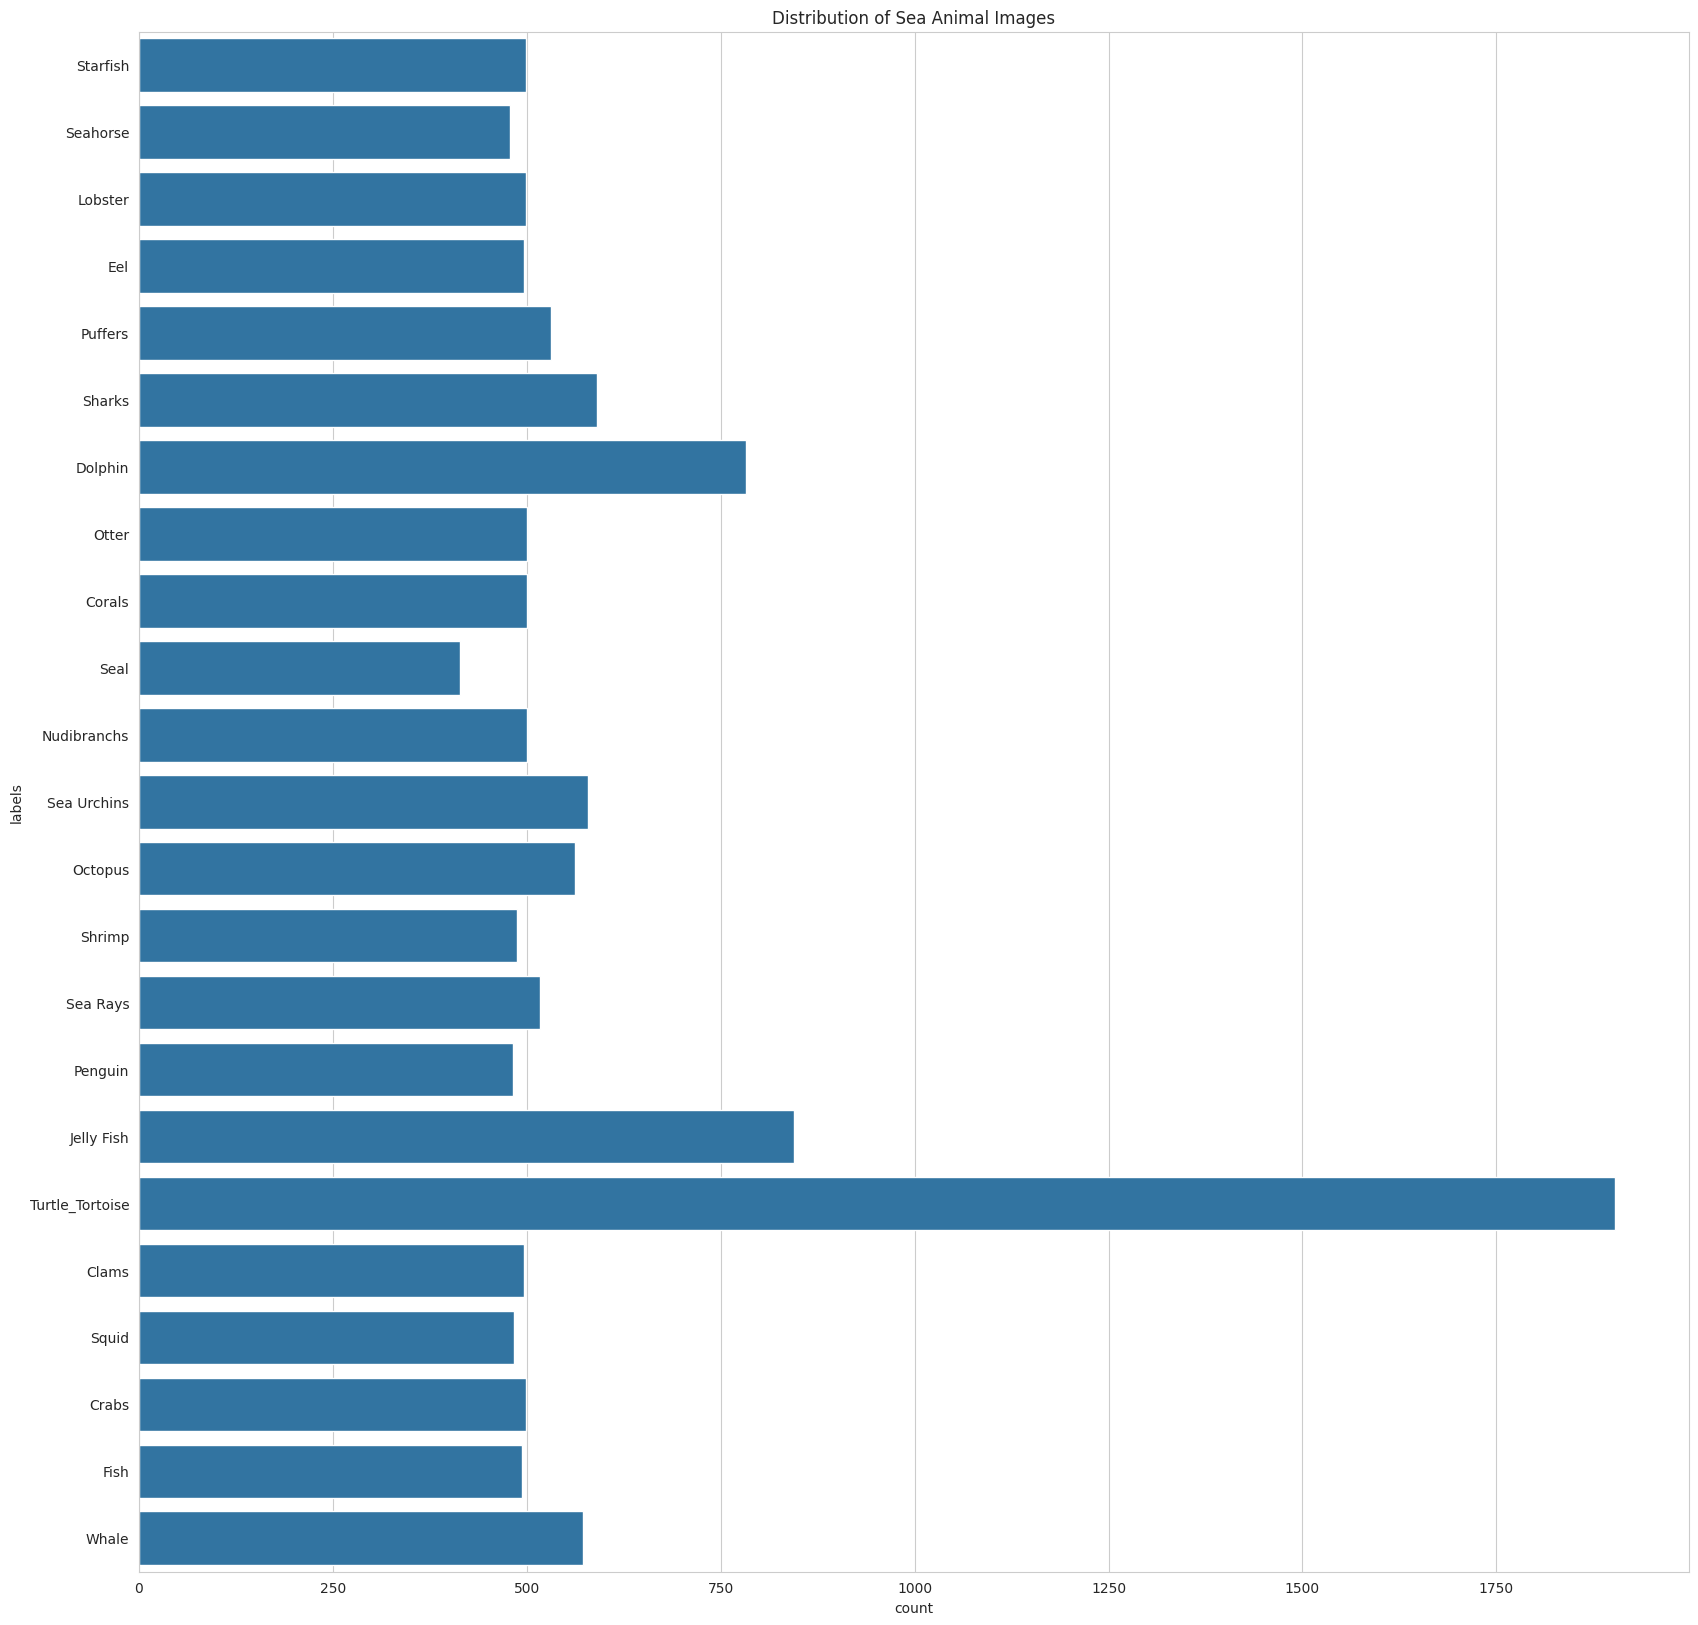

In [ ]:
#Defenisi path sumber
animal_path = "/content/drive/MyDrive/Computer_Vision/Dataset_Sea_Animals"

#buat daftar yang menyimpan data untuk setiap nama file, path file, dan label dalam data
file_name = []
labels =[]
full_path=[]

#dapatkan nama file gambar, path file, dan label satu per satu dengan looping dan simpan sebagai dataframe
for path, subdirs, files in os.walk(animal_path):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

dist_data= pd.DataFrame({"path": full_path, "file_name": file_name, "labels": labels})

#Plot distribusi gambar di setiap kelas
Label = dist_data['labels']
plt.figure(figsize=(20, 20))
sns.set_style("whitegrid")
plot_data = sns.countplot(Label)
plt.title("Distribution of Sea Animal Images")

The plot above shows that the turtle species has the highest number of images compared to the other datasets, with over 1,000 images.

## **Data Splitting**

Pada tahap ini data akan dibagi untuk keperluan pembejaran mengenali gambar. Data akan dibagi menjadi data train, validation, dan test. Ketiganya akan dipisahkan sesuai porsinya.

In [ ]:
#panggil variabel 'path' yang sudah didefenisikan pada cell sbelumnya
path_asli = "/content/drive/MyDrive/Computer_Vision/Dataset_Sea_Animals"

#membuat listuntuk menanpung data
file_name =[]
labels = []
full_path =[]

for pathlg, subdirs, files in os.walk(path_asli):
    for name in files:
      if name.lower().endswith(('.png', '.jpg', '.jpeg')):
          full_path.append(os.path.join(pathlg, name))
          labels.append(pathlg.split('/')[-1])
          file_name.append(name)

#Loop kedua untuk Data Augmentasi (Menambah ke list yang sama)
#for pathnya, subdirs, files in os.walk(path_aug):
#    for name in files:
#        if name.lower().endswith(('.png', '.jpg', '.jpeg')):
#            full_path.append(os.path.join(pathnya, name))
#            labels.append(pathnya.split('/')[-1])
#            file_name.append(name)

#Memasukkan variabel yang sudah dikumpulkan pada looping diatas menjadi sebuah dataframe
df_data = pd.DataFrame({"path": full_path, "file_name": file_name, "labels": labels})

#Melihat jumlah data gambar pada masing-masing label
df_data.groupby(['labels']).size()

,0
labels,
Clams,497
Corals,500
Crabs,499
Dolphin,782
Eel,497
Fish,494
Jelly Fish,845
Lobster,499
Nudibranchs,500


After obtaining the variables required for data separation, the next step is to split the variables into X and y.

In [ ]:
X = df_data['path']
y = df_data['labels']

In [ ]:
#Split dataset awal menjadi data tarin 80%, vaidation + test 20%
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state =300)

In [ ]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size = 0.5, stratify = y_temp, random_state = 300
)

In [ ]:
#Menyatukan kedalam masing-masing dataframe
df_tr = pd.DataFrame({'path': X_train, 'labels': y_train, 'set': 'train'})
df_val = pd.DataFrame({'path' : X_val, 'labels': y_val, 'set': 'validation'})
df_te = pd.DataFrame({'path': X_test, 'labels': y_test, 'set': 'test'})

In [ ]:
print(df_tr.groupby(['set', 'labels']).size())

set    labels         
train  Clams               407
       Corals              394
       Crabs               376
       Dolphin             634
       Eel                 402
       Fish                404
       Jelly Fish          681
       Lobster             394
       Nudibranchs         392
       Octopus             436
       Otter               407
       Penguin             390
       Puffers             438
       Sea Rays            407
       Sea Urchins         468
       Seahorse            389
       Seal                331
       Sharks              465
       Shrimp              387
       Squid               360
       Starfish            409
       Turtle_Tortoise    1527
       Whale               470
dtype: int64


In [ ]:
#Gabungkan DataFrame df_tr dan df_te
df_all = pd.concat([df_tr, df_val, df_te], ignore_index=True)

print('===========================================\n')
print(df_all.groupby(['set', 'labels']).size())
print('===========================================\n')

#Cek sampel data
print(df_all.sample(5))

#Memanggil dataset asli yang berisi keseluruhan gambar yang sesuai dengan labelnya
#inisialisasi 'path' pada cell sebelumnya
# Membuat variabel Dataset, tempat menampung data yang telah dilakukan pembagian data training dan testing
dataset_path = "/content/drive/MyDrive/Computer_Vision/"


set         labels         
test        Clams               45
            Corals              53
            Crabs               62
            Dolphin             74
            Eel                 47
                              ... 
validation  Shrimp              50
            Squid               61
            Starfish            45
            Turtle_Tortoise    188
            Whale               51
Length: 69, dtype: int64

                                                   path           labels  \
3810  /content/drive/MyDrive/Computer_Vision/Dataset...         Seahorse   
7030  /content/drive/MyDrive/Computer_Vision/Dataset...            Otter   
7578  /content/drive/MyDrive/Computer_Vision/Dataset...  Turtle_Tortoise   
6652  /content/drive/MyDrive/Computer_Vision/Dataset...          Penguin   
7687  /content/drive/MyDrive/Computer_Vision/Dataset...           Sharks   

        set  
3810  train  
7030  train  
7578  train  
6652  train  
7687  train  


In [ ]:
bad_images = []

for path in df_all['path']:
    try:
        img = Image.open(path)
        img.verify()
    except:
        bad_images.append(path)

print("Number of broken images:", len(bad_images))
print(bad_images[:5])

Number of broken images: 0
[]


Next, the data distribution is printed to verify that the data has been split correctly; subsequently, path variables are set for the original and split datasets, which will be used in the next processing stage.

In [ ]:
for index, row in tq(df_all.iterrows()):
    #Deteksi filepath
    file_path = row['path']
    if os.path.exists(file_path) == False:
        file_path = os.path.join(path, row['labels'], row['image'].split('.')[0])

    #Buat diretori tujuan
    if os.path.exists(os.path.join(dataset_path, row['set'], row['labels'])) == False:
        os.makedirs(os.path.join(dataset_path, row['set'], row['labels']))

    #Tentukan tujuan file
    dest_file_name = file_path.split('/')[-1]
    file_dest = os.path.join(dataset_path, row['set'], row['labels'], dest_file_name)

    #Salin file dari sumber tujuan
    if os.path.exists(file_dest) == False:
        shutil.copy2(file_path, file_dest)

0it [00:00, ?it/s]

## **Data Augmentation**

To help prevent overfitting—a situation where a model becomes too accustomed to the training data and fails to generalize well to new data—image augmentation is used to create new variations of each image in the dataset, thereby providing the model with a wider range of examples to learn from.

In [ ]:
#Membuat fungsi untuk melakukan rotasi berlawanan arah jarum jam
def anticlockwise_rotation(img):
    #img = cv2.cvtColor(img, 0)
    img_res = cv2.resize(img, (224, 224))
    sudut = random.randint(0, 180)
    hasil = sk_rotate(img_res, sudut)
    return img_as_ubyte(hasil)

In [ ]:
#Membuat fungsi untuk melakukan rotasi searah jarum jam
def clockwise_rotation(img):
    #img = cv2.cvtColor(img, 0)
    img_res = cv2.resize(img, (224, 224))
    sudut = random.randint(0, 180)
    hasil = sk_rotate(img_res, -sudut)
    return img_as_ubyte(hasil)

In [ ]:
#Membuat fungsi untuk membalik gambar secara vertikal dari atas ke bawah
def flip_up_down(img):
    #img = cv2.cvtColor(img, 0)
    img_res = cv2.resize(img, (224, 224))
    flip_img = np.flipud(img_res)
    return flip_img.astype(np.uint8)

In [ ]:
#Membuat fungsi untuk memberikan efek peningkatan kecerahan pada gambar
def add_brightness(img):
    #img = cv2.cvtColor(img, 0)
    img_res = cv2.resize(img, (224, 224))
    hasil = adjust_gamma(img_res, gamma=0.5, gain=1)
    return img_as_ubyte(hasil)

In [ ]:
#Membuat fungsi untuk memberikan efek blur pada gambar
def blur_image(img):
    #img = cv2.cvtColor(img, 0)
    img_res = cv2.resize(img, (224, 224))
    blurred = cv2.GaussianBlur(img, (9,9), 0)
    return blurred.astype(np.uint8)

In [ ]:
#Membuat fungsi untuk memberikan efek pergeseran acak pada gambar
def sheared(img):
    #img = cv2.cvtColor(img, 0)
    img_res = cv2.resize(img, (224, 224))
    transf =AffineTransform(shear=0.2)
    shear_image = warp(img_res, transf, mode="wrap")
    return img_as_ubyte(shear_image)

In [ ]:
def warp_shift(img):
    #img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224, 224))
    transform = AffineTransform(translation=(0, 40))
    warp_image = warp(img, transform, mode="wrap")
    return img_as_ubyte(warp_image)

In [ ]:
# Membuat variabel transformasi yang akan menyimpan semua proses pra-pemrosesan yang telah dilakukan sebelumnya
transformations = { 'rotate anticlockwise': anticlockwise_rotation,
                    'rotate clockwise': clockwise_rotation,
                    'warp shift': warp_shift,
                    'blurring image': blur_image,
                    'add brightness' : add_brightness,
                    'flip up down': flip_up_down,
                    'shear image': sheared
                  }

In [ ]:
def ensure_uint8(img):
    """Memastikan gambar dalam format uint8 (0-255) untuk OpenCV"""
    # Jika gambar dalam format float (0.0 - 1.0)
    if img.dtype == np.float64 or img.dtype == np.float32:
        return img_as_ubyte(img)
    # Jika sudah dalam format integer tapi bukan uint8
    return img.astype(np.uint8)

In [ ]:
from os.path import exists
from IPython.utils.path import target_outdated
path_train = "/content/drive/MyDrive/Computer_Vision/train"

#inisialisasi path augment
aug_path = "/content/drive/MyDrive/Computer_Vision/Augmented_Sea_Animals"

img_aug = [] #penyimpanan gambar yang telah melalui pemrosesan

#target total gambar per kelas (Asli + augmentasi)
target_total = 1500

categ = [f for f in os.listdir(path_train) if os.path.isdir(os.path.join(path_train, f))]

for kategori in categ:
    img_path = os.path.join(path_train, kategori)
    augment = os.path.join(aug_path, kategori)

    if not os.path.exists(augment):
        os.makedirs(augment, exist_ok=True)

    #ambil daftar dari gambar asli
    imgs = [os.path.join(img_path, im) for im in os.listdir(img_path)
            if im.lower().endswith(('.png', '.jpg', '.jpeg'))]

    jumlah_asli = len(imgs)

    #Hitung sisa yang perlu dibuat (target-asli)
    #jika data asli sudah >= 1500, maka tidak diaugmentasi
    need_to_generate = target_total - jumlah_asli

    if need_to_generate <= 0:
        print(f"Category {kategori} is sufficient ({jumlah_asli} images")
        continue

    print(f"Category {kategori}: Original={jumlah_asli}, create= {need_to_generate}")

    i=1
    while i <= need_to_generate:
        image = random.choice(imgs)
        try:
            ori_img = cv2.imread(image)
            if ori_img is None:
                continue

            #Konversi BGR ke RGB karena fungsi transformasi
            ori_img = cv2.cvtColor(ori_img, cv2.COLOR_BGR2RGB)
            transform_img = ori_img.copy()

            #pilih jumlah transformasi yang diterapkan
            transform_count = random.randint(1, min(3, len(transformations)))

            #Terapkan transformasi secara acak
            for _ in range(transform_count):
                key = random.choice(list(transformations))
                transform_img = transformations[key](transform_img)

            #format nama: aug_kategori_001.jpg
            new_img_name = f"aug_{kategori}_{i:03d}.jpg"
            save_path = os.path.join(augment, new_img_name)

            #Memastikan format uint8 untuk openCV
            transform_img = ensure_uint8(transform_img)

            #Konversi RGB ke BGR untuk cv2.imwrite agar warna tidak tertukar
            final_img = cv2.cvtColor(transform_img, cv2.COLOR_RGB2BGR)

            cv2.imwrite(save_path, final_img)
            i +=1

        except Exception as e:
            print(f"Failed to process {image}: {e}")
print("The dataset balancing process is complete.")

Category Turtle_Tortoise is sufficient (1527 images
Category Corals: Original=394, create= 1106
Category Sharks: Original=465, create= 1035
Category Otter: Original=407, create= 1093
Category Crabs: Original=376, create= 1124
Category Penguin: Original=390, create= 1110
Category Jelly Fish: Original=681, create= 819
Category Nudibranchs: Original=392, create= 1108
Category Whale: Original=470, create= 1030
Category Octopus: Original=436, create= 1064
Category Sea Rays: Original=407, create= 1093
Category Seahorse: Original=389, create= 1111
Category Starfish: Original=409, create= 1091
Category Shrimp: Original=387, create= 1113
Category Lobster: Original=394, create= 1106
Category Sea Urchins: Original=468, create= 1032
Category Squid: Original=360, create= 1140
Category Clams: Original=407, create= 1093
Category Seal: Original=331, create= 1169
Category Puffers: Original=438, create= 1062
Category Fish: Original=404, create= 1096
Category Eel: Original=402, create= 1098
Category Dolp

(array([   0.,  200.,  400.,  600.,  800., 1000., 1200., 1400.]),
 [Text(0.0, 0, '0'),
  Text(200.0, 0, '200'),
  Text(400.0, 0, '400'),
  Text(600.0, 0, '600'),
  Text(800.0, 0, '800'),
  Text(1000.0, 0, '1000'),
  Text(1200.0, 0, '1200'),
  Text(1400.0, 0, '1400')])

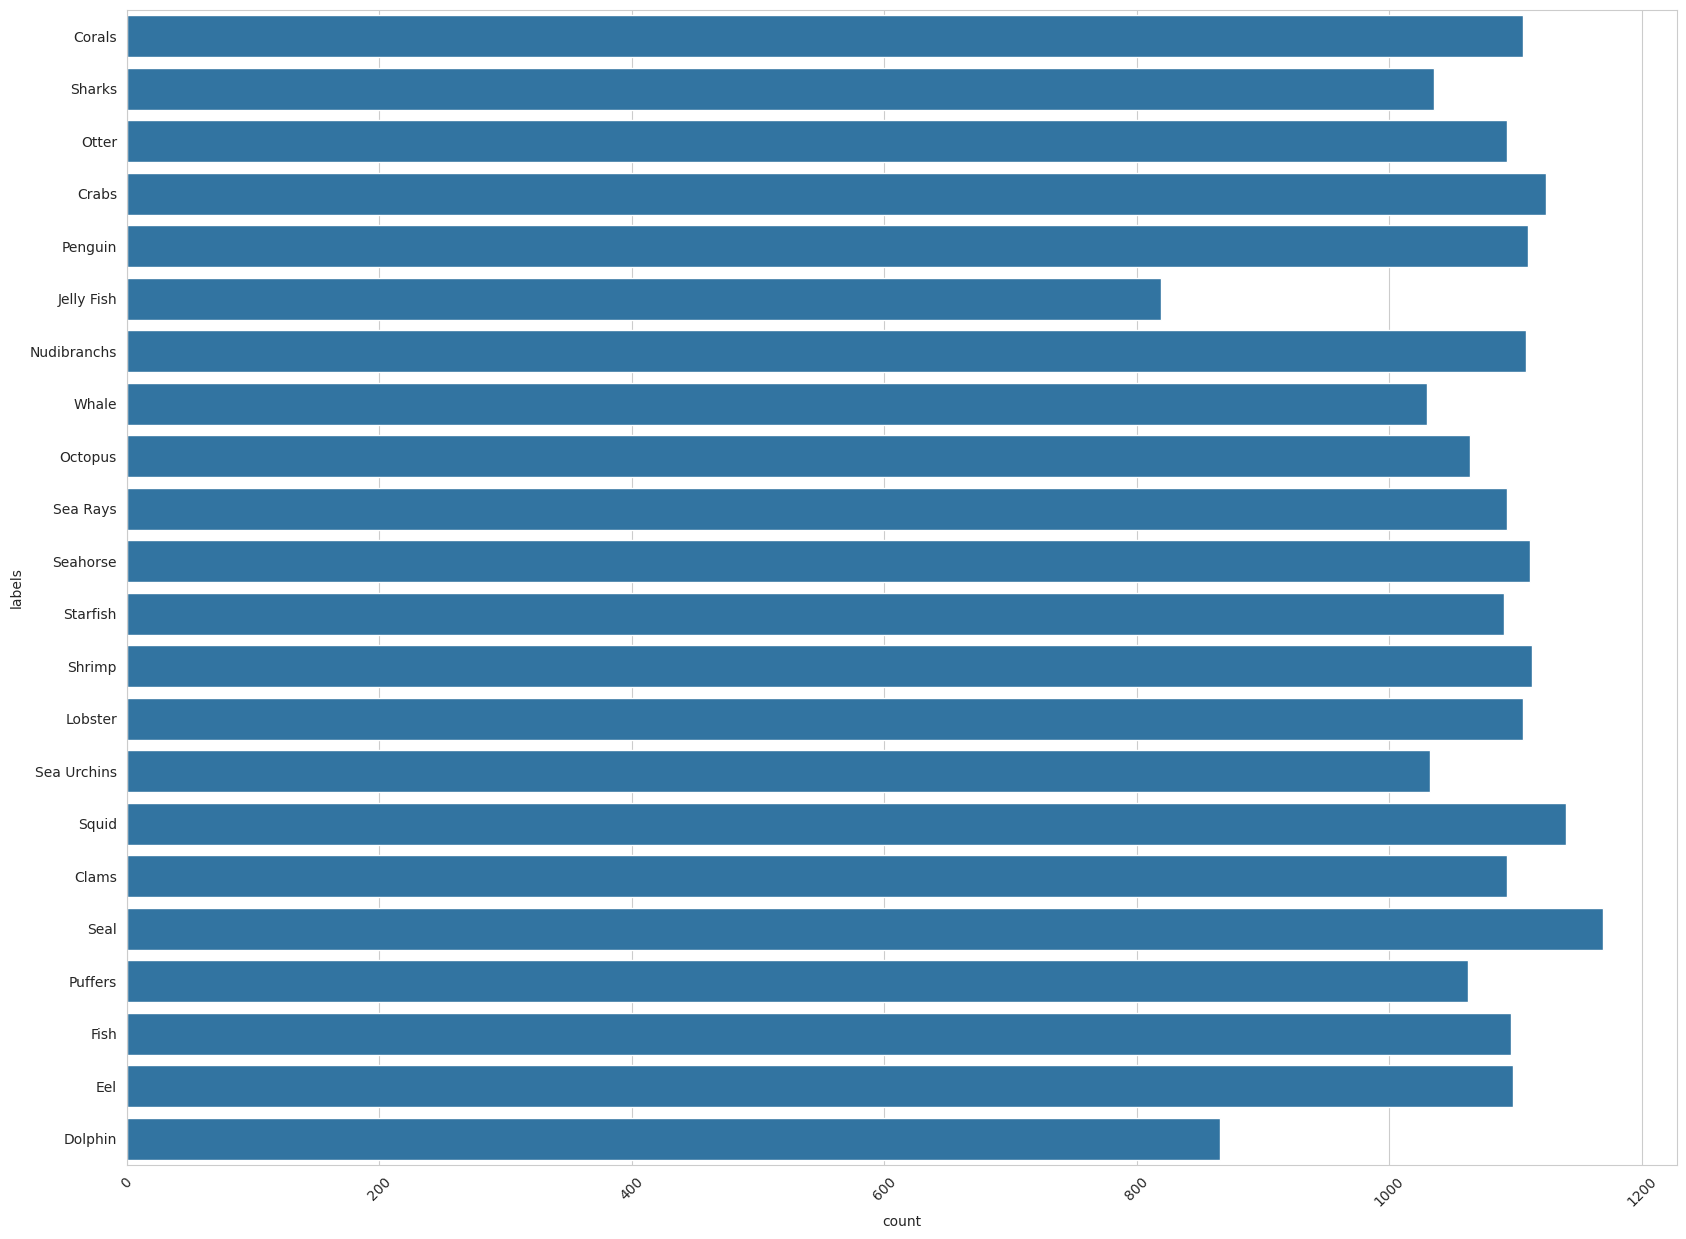

In [ ]:
#Melihat plot seluruh gambar setelah di augmentasi

#inisialisasi path sumber
#path_asli = "/content/drive/MyDrive/Computer_Vision/Dataset_Sea_Animals"
path_aug = "/content/drive/MyDrive/Computer_Vision/Augmented_Sea_Animals"

#Buat daftar yang menyimpan data
file_name = []
labels =[]
full_path=[]

#dapatkan nama file gambar, path file, dan label satu per satu dengan looping dan simpan sebagai dataframe
#for pathnya, subdirs, files in os.walk(path_aug):
#    for name in files:
#        full_path.append(os.path.join(pathnya, name))
#        labels.append(pathnya.split('/')[-1])
#        file_name.append(name)

#Loop kedua untuk Data Augmentasi (Menambah ke list yang sama)
for pathnya, subdirs, files in os.walk(path_aug):
    for name in files:
        if name.lower().endswith(('.png', '.jpg', '.jpeg')):
            full_path.append(os.path.join(pathnya, name))
            labels.append(pathnya.split('/')[-1])
            file_name.append(name)

dist_data= pd.DataFrame({"path": full_path, "file_name": file_name, "labels": labels})

#Plot distribusi gambar di setiap kelas
Label = dist_data['labels']
plt.figure(figsize=(20, 15))
sns.set_style("whitegrid")
plot_data = sns.countplot(Label)

plt.xticks(rotation=45)

Augmentation was performed to prevent data imbalance. Each class underwent augmentation to increase the number of images to 1,500. Subsequently, the augmented images are consolidated into the training folder.

In [ ]:
#Menyatukan citra augmentasi kedalam folder train
#mendefenisikan path_train dan aug_path pada sel sebelumnya

categ_aug = [f for f in os.listdir(aug_path) if os.path.isdir(os.path.join(aug_path, f))]

print("Memulai proses penyalinan ke folder train")

for kategori in categ_aug:
  fol_asal = os.path.join(aug_path, kategori)
  fol_tujuan = os.path.join(path_train, kategori)

  os.makedirs(fol_tujuan, exist_ok=True)

  #ambil semua citra dari folder augmentasi
  files = [f for f in os.listdir(fol_asal) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

  counter = 0
  for file_name in files:
    src_file = os.path.join(fol_asal, file_name)
    dst_file = os.path.join(fol_tujuan, file_name)

    #salin file fisik gambar
    shutil.copy(src_file, dst_file)
    counter += 1

  print(f"Category {kategori}: Successfully copied {counter} augmented images to the train folder.")

print("\nAll augmented images have been successfully merged into the 'train' folder!")

Memulai proses penyalinan ke folder train
Category Turtle_Tortoise: Successfully copied 0 augmented images to the train folder.
Category Corals: Successfully copied 1106 augmented images to the train folder.
Category Sharks: Successfully copied 1035 augmented images to the train folder.
Category Otter: Successfully copied 1093 augmented images to the train folder.
Category Crabs: Successfully copied 1124 augmented images to the train folder.
Category Penguin: Successfully copied 1110 augmented images to the train folder.
Category Jelly Fish: Successfully copied 819 augmented images to the train folder.
Category Nudibranchs: Successfully copied 1108 augmented images to the train folder.
Category Whale: Successfully copied 1030 augmented images to the train folder.
Category Octopus: Successfully copied 1064 augmented images to the train folder.
Category Sea Rays: Successfully copied 1093 augmented images to the train folder.
Category Seahorse: Successfully copied 1111 augmented images to

In [ ]:
#List untuk menapung data train baru
file_name = []
labels = []
full_path = []

#menggunakan walk di folder path_train saja
for pathnya, subdirs, files in os.walk(path_train):
  for name in files:
    if name.lower().endswith(('.png', '.jpg', '.jpeg')):
      full_path.append(os.path.join(pathnya, name))
      labels.append(pathnya.split('/')[-1])
      file_name.append(name)

#membuat dataframe df_tr_final
df_tr_final = pd.DataFrame({'path': full_path, 'file_name': file_name, 'labels': labels})
df_tr_final['set'] = 'train'

#cek hasil akhir jumlah data per kelas
print(df_tr_final.groupby(['set', 'labels']).size())

set    labels         
train  Clams              1500
       Corals             1500
       Crabs              1500
       Dolphin            1500
       Eel                1500
       Fish               1500
       Jelly Fish         1500
       Lobster            1500
       Nudibranchs        1500
       Octopus            1500
       Otter              1500
       Penguin            1500
       Puffers            1500
       Sea Rays           1500
       Sea Urchins        1500
       Seahorse           1500
       Seal               1500
       Sharks             1500
       Shrimp             1500
       Squid              1500
       Starfish           1500
       Turtle_Tortoise    1527
       Whale              1500
dtype: int64


The dataset has been split into training and testing data, with each stored on Google Drive.

In [ ]:
#Proses zip file
#Bersihkan folder sementara di Runtime
!rm -rf /content/data_lokal

In [ ]:
#Membuat zip dari folder train dan test yang ada di Drive
!zip -r "/content/drive/MyDrive/Computer_Vision/dataset_gambar_laut.zip" \
"/content/drive/MyDrive/Computer_Vision/train"\
"/content/drive/MyDrive/Computer_Vision/validation"\
"/content/drive/MyDrive/Computer_Vision/test"

Output streaming akan dipotong hingga 5000 baris terakhir.
  adding: content/drive/MyDrive/Computer_Vision/train/Eel/aug_Eel_391.jpg (deflated 1%)
  adding: content/drive/MyDrive/Computer_Vision/train/Eel/aug_Eel_392.jpg (deflated 1%)
  adding: content/drive/MyDrive/Computer_Vision/train/Eel/aug_Eel_393.jpg (deflated 1%)
  adding: content/drive/MyDrive/Computer_Vision/train/Eel/aug_Eel_394.jpg (deflated 1%)
  adding: content/drive/MyDrive/Computer_Vision/train/Eel/aug_Eel_395.jpg (deflated 1%)
  adding: content/drive/MyDrive/Computer_Vision/train/Eel/aug_Eel_396.jpg (deflated 1%)
  adding: content/drive/MyDrive/Computer_Vision/train/Eel/aug_Eel_397.jpg (deflated 1%)
  adding: content/drive/MyDrive/Computer_Vision/train/Eel/aug_Eel_398.jpg (deflated 1%)
  adding: content/drive/MyDrive/Computer_Vision/train/Eel/aug_Eel_399.jpg (deflated 1%)
  adding: content/drive/MyDrive/Computer_Vision/train/Eel/aug_Eel_400.jpg (deflated 1%)
  adding: content/drive/MyDrive/Computer_Vision/train/Eel/aug

In [5]:
# Memindahkan dan mengekstrak ke folder /content/data_lokal
!unzip -q "/content/drive/MyDrive/Computer_Vision/dataset_gambar_laut.zip" -d /content/data_lokal

In [6]:
path_zip = '/content/data_lokal'
print(os.listdir(path_zip))

['content']


## **Image Data Generator**

In this stage, the ImageDataGenerator is used to divide the dataset into training and validation sets while normalizing the images by rescaling the pixel values.

In [14]:
#Defenisikan direktori tarining dan test
base_zip = '/content/data_lokal/content/drive/MyDrive/Computer_Vision/'
train_zip = os.path.join(base_zip, 'train')
val_zip = os.path.join(base_zip, 'validation')
test_zip = os.path.join(base_zip, 'test')
#TRAIN_DIR = "/content/drive/MyDrive/Colab Notebooks/Computer Vision/train/"
#TEST_DIR = "/content/drive/MyDrive/Colab Notebooks/Computer Vision/test/"

train_sea_urchins = os.path.join(train_zip + '/Sea Urchins')
train_whale = os.path.join(train_zip + '/Whale')
train_fish = os.path.join(train_zip + '/Fish')
train_clams = os.path.join(train_zip + '/Clams')
train_seal = os.path.join(train_zip + '/Seal')
train_sea_rays = os.path.join(train_zip + '/Sea Rays')
train_octopus = os.path.join(train_zip + '/Octopus')
train_nudibranch = os.path.join(train_zip + '/Nudibranchs')
train_shrimp = os.path.join(train_zip + '/Shrimp')
train_eel = os.path.join(train_zip + '/Eel')
train_lobster = os.path.join(train_zip + '/Lobster')
train_seahorse = os.path.join(train_zip + '/Seahorse')
train_coral = os.path.join(train_zip + '/Corals')
train_squid = os.path.join(train_zip + '/Squid')
train_dolphin = os.path.join(train_zip + '/Dolphin')
train_crabs = os.path.join(train_zip+ '/Crabs')
train_puffers = os.path.join(train_zip + '/Puffers')
train_penguin = os.path.join(train_zip + '/Penguin')
train_turtle = os.path.join(train_zip + '/Turtle_Tortoise')
train_sharks = os.path.join(train_zip + '/Sharks')
train_starfish = os.path.join(train_zip + '/Starfish')
train_otter= os.path.join(train_zip + '/Otter')
train_jelly_fish = os.path.join(train_zip + '/Jelly Fish')

test_sea_urchins = os.path.join(test_zip + '/Sea Urchins')
test_whale = os.path.join(test_zip+ '/Whale')
test_fish = os.path.join(test_zip + '/Fish')
test_clams = os.path.join(test_zip + '/Clams')
test_seal = os.path.join(test_zip + '/Seal')
test_sea_rays = os.path.join(test_zip + '/Sea Rays')
test_octopus = os.path.join(test_zip + '/Octopus')
test_nudibranch = os.path.join(test_zip + '/Nudibranchs')
test_shrimp = os.path.join(test_zip + '/Shrimp')
test_eel = os.path.join(test_zip + '/Eel')
test_lobster = os.path.join(test_zip + '/Lobster')
test_seahorse = os.path.join(test_zip + '/Seahorse')
test_coral = os.path.join(test_zip+ '/Corals')
test_squid = os.path.join(test_zip + '/Squid')
test_dolphin = os.path.join(test_zip + '/Dolphin')
test_crabs = os.path.join(test_zip + '/Crabs')
test_puffers = os.path.join(test_zip + '/Puffers')
test_penguin = os.path.join(test_zip + '/Penguin')
test_turtle = os.path.join(test_zip + '/Turtle_Tortoise')
test_sharks = os.path.join(test_zip + '/Sharks')
test_starfish = os.path.join(test_zip + '/Starfish')
test_otter= os.path.join(test_zip + '/Otter')
test_jelly_fish = os.path.join(test_zip + '/Jelly Fish')

print("Total number of Sea Urchins in training set: ", len(os.listdir(train_sea_urchins)))
print("Total number of Whale in training set: ", len(os.listdir(train_whale)))
print("Total number of Fish in training set: ", len(os.listdir(train_fish)))
print("Total number of Clams in training set: ", len(os.listdir(train_clams)))
print("Total number of Seal in training set: ", len(os.listdir(train_seal)))
print("Total number of Sea Rays in training set: ", len(os.listdir(train_sea_rays)))
print("Total number of Octopus in training set: ", len(os.listdir(train_octopus)))
print("Total number of Nudibranchs in training set: ", len(os.listdir(train_nudibranch)))
print("Total number of Shrimp in training set: ", len(os.listdir(train_shrimp)))
print("Total number of Eel in training set: ", len(os.listdir(train_eel)))
print("Total number of Lobster in training set: ", len(os.listdir(train_lobster)))
print("Total number of Seahorse in training set: ", len(os.listdir(train_seahorse)))
print("Total number of Coral in training set: ", len(os.listdir(train_coral)))
print("Total number of Squid in training set: ", len(os.listdir(train_squid)))
print("Total number of Dolphin in training set: ", len(os.listdir(train_dolphin)))
print("Total number of Crabs in training set: ", len(os.listdir(train_crabs)))
print("Total number of Puffers in training set: ", len(os.listdir(train_puffers)))
print("Total number of Penguin in training set: ", len(os.listdir(train_penguin)))
print("Total number of Turtle and Tortoise in training set: ", len(os.listdir(train_turtle)))
print("Total number of Shark in training set: ", len(os.listdir(train_sharks)))
print("Total number of Starfish in training set: ", len(os.listdir(train_starfish)))
print("Total number of Otter in training set: ", len(os.listdir(train_otter)))
print("Total number of Jelly Fish in training set: ", len(os.listdir(train_jelly_fish)))

print("Total number of Sea Urchins in test set: ", len(os.listdir(test_sea_urchins)))
print("Total number of Whale in test set: ", len(os.listdir(test_whale)))
print("Total number of Fish in test set: ", len(os.listdir(test_fish)))
print("Total number of Clams in test set: ", len(os.listdir(test_clams)))
print("Total number of Seal in test set: ", len(os.listdir(test_seal)))
print("Total number of Sea Rays in test set: ", len(os.listdir(test_sea_rays)))
print("Total number of Octopus in test set: ", len(os.listdir(test_octopus)))
print("Total number of Nudibranchs in test set: ", len(os.listdir(test_nudibranch)))
print("Total number of Shrimp in test set: ", len(os.listdir(test_shrimp)))
print("Total number of Eel in test set: ", len(os.listdir(test_eel)))
print("Total number of Lobster in test set: ", len(os.listdir(test_lobster)))
print("Total number of Seahorse in test set: ", len(os.listdir(test_seahorse)))
print("Total number of Coral in test set: ", len(os.listdir(test_coral)))
print("Total number of Squid in test set: ", len(os.listdir(test_squid)))
print("Total number of Dolphin in test set: ", len(os.listdir(test_dolphin)))
print("Total number of Crabs in test set: ", len(os.listdir(test_crabs)))
print("Total number of Puffers in test set: ", len(os.listdir(test_puffers)))
print("Total number of Penguin in test set: ", len(os.listdir(test_penguin)))
print("Total number of Turtle and Tortoise in test set: ", len(os.listdir(test_turtle)))
print("Total number of Shark in test set: ", len(os.listdir(test_sharks)))
print("Total number of Starfish in test set: ", len(os.listdir(test_starfish)))
print("Total number of Otter in test set: ", len(os.listdir(test_otter)))
print("Total number of Jelly Fish in test set: ", len(os.listdir(test_jelly_fish)))

Total number of Sea Urchins in training set:  1500
Total number of Whale in training set:  1500
Total number of Fish in training set:  1500
Total number of Clams in training set:  1500
Total number of Seal in training set:  1500
Total number of Sea Rays in training set:  1500
Total number of Octopus in training set:  1500
Total number of Nudibranchs in training set:  1500
Total number of Shrimp in training set:  1500
Total number of Eel in training set:  1500
Total number of Lobster in training set:  1500
Total number of Seahorse in training set:  1500
Total number of Coral in training set:  1500
Total number of Squid in training set:  1500
Total number of Dolphin in training set:  1500
Total number of Crabs in training set:  1500
Total number of Puffers in training set:  1500
Total number of Penguin in training set:  1500
Total number of Turtle and Tortoise in training set:  1527
Total number of Shark in training set:  1500
Total number of Starfish in training set:  1500
Total number 

In [15]:
#Buat objek ImageDataGenerator yang menormalkan gambar
train_datagen =ImageDataGenerator(#rescale=1./255, #untuk CNN
                            #preprocessing_function = preprocessing_input, #untuk transfer learning mobilenetV2
                             preprocessing_function = eff_preprocessing #untuk transferlearning efficientnet
)

validation_datagen = ImageDataGenerator(#rescale=1./255, #untuk CNN
                            #preprocessing_function = preprocessing_input, #untuk transfer learning mobilenetV2
                             preprocessing_function = eff_preprocessing #untuk transferlearning efficientnet
)

test_datagen =ImageDataGenerator(#rescale=1./255, #untuk CNN
                            #preprocessing_function = preprocessing_input, #untuk transfer learning mobilenetV2
                             preprocessing_function = eff_preprocessing #untuk transferlearning efficientnet
)

train_generator = train_datagen.flow_from_directory(train_zip,
                                              #batch_size = 64,
                                              batch_size =32, #untuk efficientnetb0
                                              #target_size =(150, 150),
                                              target_size =(224, 224), #efficientnetb0
                                              color_mode='rgb',
                                              class_mode ='categorical',
                                              shuffle=True)

validation_generator = validation_datagen.flow_from_directory(val_zip,
                                                   #batch_size=64,
                                                   #target_size=(150, 150),
                                                   batch_size=32,
                                                   target_size = (224,224),
                                                   color_mode='rgb',
                                                   class_mode='categorical',
                                                   shuffle=False)

test_generator = test_datagen.flow_from_directory(test_zip,
                                                  batch_size=1,
                                                  #target_size=(150, 150),
                                                  target_size =(224, 224),
                                                  color_mode='rgb',
                                                  class_mode='categorical',
                                                  shuffle=False)

Found 34527 images belonging to 23 classes.
Found 1371 images belonging to 23 classes.
Found 1372 images belonging to 23 classes.


Image preprocessing was performed using ImageDataGenerator, which was also used to partition the dataset into training, validation, and testing sets. The final dataset comprised 34,527 training images, 1,371 validation images, and 1,372 testing images, all distributed across 23 classes.

## **Pembangunan Model dengan Skema Parameter Tuning**

### **3. Skema Transfer Learning EfficientNetB0**

In [9]:
base_model_eff = tf.keras.applications.EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model_eff.trainable = False #membekukan bobot

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [10]:
n =train_generator.num_classes

model_efn = tf.keras.models.Sequential([
    base_model_eff,

    tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(n, activation='softmax')
])

In [11]:
model_efn.compile(
    optimizer = tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

class StopAtThreshold(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('val_accuracy') >= 0.95:
            print(f"\n[INFO] Validation Accuracy mencapai {logs.get('val_accuracy'):.2%}")
            self.model.stop_training =True

custom_stop_eff = StopAtThreshold()

checkpoint_stage1 = ModelCheckpoint(
    filepath='/content/drive/MyDrive/Computer_Vision/efficientnet_stage1.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

In [12]:
history_stage1 = model_efn.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator,
    callbacks = [checkpoint_stage1, early_stop, reduce_lr, custom_stop_eff],
    verbose=1
)

Epoch 1/50
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.5286 - loss: 1.6994
Epoch 1: val_accuracy improved from None to 0.83589, saving model to /content/drive/MyDrive/Computer_Vision/efficientnet_stage1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Computer_Vision/efficientnet_stage1.keras
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 162s 115ms/step - accuracy: 0.6261 - loss: 1.2943 - val_accuracy: 0.8359 - val_loss: 0.5617 - learning_rate: 1.0000e-04
Epoch 2/50
1078/1079 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7326 - loss: 0.8872
Epoch 2: val_accuracy improved from 0.83589 to 0.85193, saving model to /content/drive/MyDrive/Computer_Vision/efficientnet_stage1.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Computer_Vision/efficientnet_stage1.keras
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 119s 63ms/step - accuracy: 0.7404 - loss: 0.8612 - val_accuracy: 0.8519 - val_loss: 0.5423 - learning_rate: 1.0000e-04
Epoch 3/50
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/

#### **Fine Tuning**

In [24]:
model_efn = tf.keras.models.load_model('/content/drive/MyDrive/Computer_Vision/efficientnet_stage1.keras')

In [25]:
base_model_eff = model_efn.layers[0]

base_model_eff.trainable =True

#Freeze sebagian besar layer
for layer in base_model_eff.layers[:-30]:
    layer.trainable = False

In [26]:
model_efn.compile(
    optimizer= tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [27]:
checkpoint_stage2 = ModelCheckpoint(
    filepath='/content/drive/MyDrive/Computer_Vision/efficientnet_finetune.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop_ft = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_ft = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

In [28]:
history_stage2 = model_efn.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator,
    callbacks=[
        checkpoint_stage2,
        early_stop_ft,
        reduce_lr_ft,
        custom_stop_eff
    ],
    verbose=1
)

Epoch 1/20
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.7130 - loss: 0.9643
Epoch 1: val_accuracy improved from None to 0.83807, saving model to /content/drive/MyDrive/Computer_Vision/efficientnet_finetune.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Computer_Vision/efficientnet_finetune.keras
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 125s 88ms/step - accuracy: 0.7313 - loss: 0.8977 - val_accuracy: 0.8381 - val_loss: 0.5852 - learning_rate: 1.0000e-05
Epoch 2/20
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7679 - loss: 0.7650
Epoch 2: val_accuracy improved from 0.83807 to 0.85120, saving model to /content/drive/MyDrive/Computer_Vision/efficientnet_finetune.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Computer_Vision/efficientnet_finetune.keras
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 63s 59ms/step - accuracy: 0.7725 - loss: 0.7441 - val_accuracy: 0.8512 - val_loss: 0.5551 - learning_rate: 1.0000e-05
Epoch 3/20
1078/1079 ━━━━━━━━━━━━━━━━━━━━ 0s

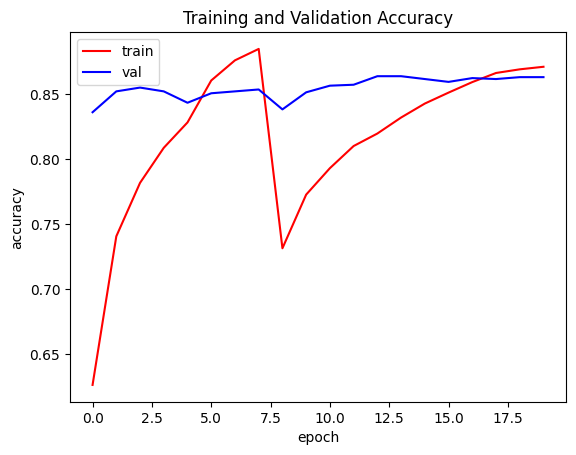

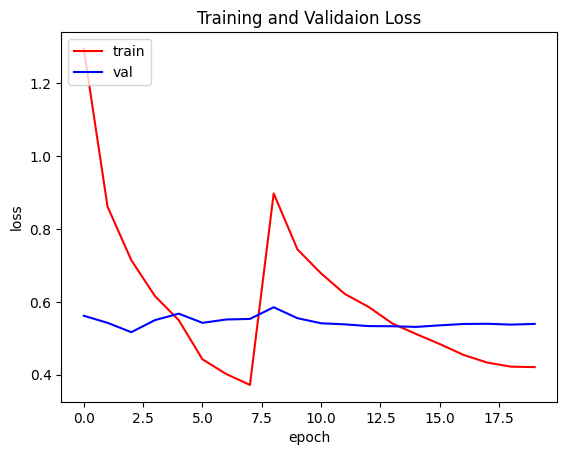

In [29]:
acc_efn = history_stage1.history['accuracy'] + history_stage2.history['accuracy']
val_acc_efn = history_stage1.history['val_accuracy'] + history_stage2.history['val_accuracy']
loss_efn = history_stage1.history['loss'] + history_stage2.history['loss']
val_loss_efn = history_stage1.history['val_loss'] + history_stage2.history['val_loss']

epochs_efn = range(len(acc_efn))

plt.plot(epochs_efn, acc_efn, 'r')
plt.plot(epochs_efn, val_acc_efn, 'b')
plt.title('Training and Validation Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(epochs_efn, loss_efn, 'r')
plt.plot(epochs_efn, val_loss_efn, 'b')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.title('Training and Validaion Loss')
plt.show()

In [30]:
#Evaluasi data train
train_acceff = history_stage2.history['accuracy'][-1] * 100
val_acceff = max(history_stage2.history['val_accuracy']) * 100

#train_acceff = history_stage1.history['accuracy'][-1] * 100
#val_acceff = max(history_stage1.history['val_accuracy']) * 100

print(f"Train Accuracy: {train_acceff:.2f}%")
print(f"Validation Accuracy: {val_acceff:.2f}%")

Train Accuracy: 87.09%
Validation Accuracy: 86.36%


In [31]:
#Evaluasi data test
best_model_ft = load_model('/content/drive/MyDrive/Computer_Vision/efficientnet_finetune.keras')
#best_model_ft = load_model('/content/drive/MyDrive/Computer_Vision/efficientnet_stage1.keras')

test_losseff, test_acceff = best_model_ft.evaluate(test_generator)
test_acc_percent = test_acceff * 100

print(f"Test Accuracy: {test_acc_percent:.2f}%")

1372/1372 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.8550 - loss: 0.5668
Test Accuracy: 85.50%


The final EfficientNetB0 model achieved a training accuracy of 87.09%, indicating that it learned the training data effectively. The model obtained a validation accuracy of 86.36%, demonstrating good generalization performance on unseen validation data. Furthermore, the model achieved a test accuracy of 85.50%, confirming its ability to classify unseen images reliably and meeting the target performance of over 85%.

## **Menyimpan Model**

In [32]:
#1.SaveModel

n =train_generator.num_classes

model_efn = tf.keras.models.Sequential([
    base_model_eff,

    tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(n, activation='softmax')
])

#Ekspor model menjadi SaveModel
model_efn.export("/content/drive/MyDrive/Computer_Vision/save_model")

Saved artifact at '/content/drive/MyDrive/Computer_Vision/save_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_2940')
Output Type:
  TensorSpec(shape=(None, 23), dtype=tf.float32, name=None)
Captures:
  138207617435984: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  138207617437520: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  138210896134224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138210895037648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138210942324560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138209665883728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138210896143824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138209665881232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138210895041104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138210893867792: TensorSpec

In [36]:
#2. Konversi SaveModel ke TF-Lite
from tensorflow.keras.models import load_model

save_path = '/content/drive/MyDrive/Computer_Vision/save_model'

# Konversi model Keras ke TF-Lite
converter = tf.lite.TFLiteConverter.from_saved_model(save_path)

tflite_model = converter.convert()

with open('/content/drive/MyDrive/Computer_Vision/tflite/model_eff.tflite', 'wb') as f:
    f.write(tflite_model)

In [38]:
print(train_generator.class_indices)
class_names = list(train_generator.class_indices.keys())
output_path = '/content/drive/MyDrive/Computer_Vision/tflite/labels.txt'

with open(output_path, 'w') as f:
    for name in class_names:
        f.write(f"{name}\n")

print("The labels.txt file was successfully generated automatically from the train_generator!")

{'Clams': 0, 'Corals': 1, 'Crabs': 2, 'Dolphin': 3, 'Eel': 4, 'Fish': 5, 'Jelly Fish': 6, 'Lobster': 7, 'Nudibranchs': 8, 'Octopus': 9, 'Otter': 10, 'Penguin': 11, 'Puffers': 12, 'Sea Rays': 13, 'Sea Urchins': 14, 'Seahorse': 15, 'Seal': 16, 'Sharks': 17, 'Shrimp': 18, 'Squid': 19, 'Starfish': 20, 'Turtle_Tortoise': 21, 'Whale': 22}
The labels.txt file was successfully generated automatically from the train_generator!


In [39]:
!pip install tensorflowjs

INFO: pip is looking at multiple versions of tf-keras to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of wheel to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 97.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.9 MB/s eta 0:00:00
  Attempting uninstall: wheel
    Found existing installation: wheel 0.47.0
    Uninstalling wheel-0.47.0:
      Successfully uninstalled wheel-0.47.0
  Attempting un

In [1]:
#3. Konversi dari SaveModel ke TF-js
import tensorflow as tf
import tensorflowjs as tfjs

!tensorflowjs_converter --input_format=tf_saved_model /content/drive/MyDrive/Computer_Vision/save_model /content/drive/MyDrive/Computer_Vision/tfjs_model


print("Konversi ke TensorFlow.js berhasil!")

2026-07-04 18:27:16.106951: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783189636.128873   19986 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783189636.137451   19986 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783189636.155593   19986 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783189636.155639   19986 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783189636.155645   19986 computation_placer.cc:177] computation placer alr

In [2]:
!pip freeze > requirements.txt

In [3]:
# Konten teks menggunakan sintaks Markdown
isi_readme = """# Computer Vision for Sea Animal Classification

This project implements an image classification model for sea animal recognition using a Transfer Learning approach with EfficientNetB0. The dataset consists of underwater images belonging to 23 sea animal classes.

Offline data augmentation was performed manually by generating augmented images and storing them in a separate folder. The original dataset was divided into training, validation, and testing sets. The augmented images were added only to the training dataset to improve the model's generalization capability.

## 📂 Dataset

- **Number of Classes:** 23
- **Training Images:** 34,527
- **Validation Images:** 1,371
- **Test Images:** 1,372

## 🛠️ Installation

```bash
pip install -r requirements.txt
```

## 🧠 Model Architecture

The model uses **Transfer Learning** with **EfficientNetB0** as the feature extractor, followed by a custom CNN classification head. Fine-tuning was performed by unfreezing the last 30 layers of EfficientNetB0 and retraining the model using a learning rate of **1e-5**.

Architecture:

- EfficientNetB0 (ImageNet pretrained)
- Conv2D (64 filters, 3×3, ReLU)
- BatchNormalization
- GlobalAveragePooling2D
- Dense (256 units, ReLU)
- BatchNormalization
- Dropout (0.4)
- Dense (23 classes, Softmax)

## 📊 Model Performance

| Metric | Result |
|--------|-------:|
| Train Accuracy | **87.09%** |
| Validation Accuracy | **86.36%** |
| Test Accuracy | **85.50%** |

The final fine-tuned model achieved more than **85% accuracy** on the training, validation, and test datasets, demonstrating good generalization performance.

## 📁 Output Files

- **efficientnet_finetune.keras** — Final trained Keras model.
- **saved_model/** — TensorFlow SavedModel format for deployment and serving.
- **tfjs_model/** — TensorFlow.js model for web-based applications.
- **model_eff.tflite** — TensorFlow Lite model for deployment.
- **labels.txt** — Class labels generated automatically from the training dataset.
- **README.md** — Project documentation.

## 👨‍💻 Author

**Srie Wahyudhanis Hadis**
Machine Learning Engineer
"""

# Membuat dan menulis ke file README.md
with open("README.md", "w", encoding="utf-8") as file:
    file.write(isi_readme)

print("File README.md berhasil dibuat!")

File README.md berhasil dibuat!


## **Testing**

In [4]:
save_path = '/content/drive/MyDrive/Computer_Vision/efficientnet_finetune.keras'

model= tf.keras.models.load_model(save_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


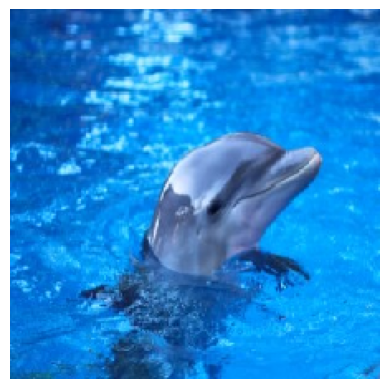

In [18]:
from tensorflow.keras.preprocessing import image

#Mengambil gambar dari google drive
from google.colab import drive
drive.mount('/content/drive')

img_path = '/content/drive/MyDrive/Computer_Vision/test/Dolphin/Dolphin_313.jpg'

# Load gambar
img = image.load_img(img_path, target_size=(224, 224))

# Tampilkan gambar
plt.imshow(img)
plt.axis('off')
plt.show()

In [19]:
#Preprocessing dan inference
img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = eff_preprocessing(img_array)

prediction = model.predict(img_array)

predicted_class = np.argmax(prediction)

confidence = np.max(prediction) * 100

print(f"Predicted Class : {predicted_class}")
print(f"Confidence      : {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Predicted Class : 3
Confidence      : 99.96%


In [20]:
print(train_generator.class_indices)
class_names = list(train_generator.class_indices.keys())
print(class_names)

{'Clams': 0, 'Corals': 1, 'Crabs': 2, 'Dolphin': 3, 'Eel': 4, 'Fish': 5, 'Jelly Fish': 6, 'Lobster': 7, 'Nudibranchs': 8, 'Octopus': 9, 'Otter': 10, 'Penguin': 11, 'Puffers': 12, 'Sea Rays': 13, 'Sea Urchins': 14, 'Seahorse': 15, 'Seal': 16, 'Sharks': 17, 'Shrimp': 18, 'Squid': 19, 'Starfish': 20, 'Turtle_Tortoise': 21, 'Whale': 22}
['Clams', 'Corals', 'Crabs', 'Dolphin', 'Eel', 'Fish', 'Jelly Fish', 'Lobster', 'Nudibranchs', 'Octopus', 'Otter', 'Penguin', 'Puffers', 'Sea Rays', 'Sea Urchins', 'Seahorse', 'Seal', 'Sharks', 'Shrimp', 'Squid', 'Starfish', 'Turtle_Tortoise', 'Whale']


In [21]:
print(f"Ini gambar {class_names[predicted_class]}")

Ini gambar Dolphin
